In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv(r"D:\DA\projects\SLA_project\raw_quick_commerce_for_eda.csv")
df_raw = df.copy()  # untouched backup

STRUCTURE CHECK

In [42]:
df.shape


(13065, 45)

In [43]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13065 entries, 0 to 13064
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   feedback_id             13065 non-null  int64  
 1   order_id                13065 non-null  int64  
 2   customer_id             13065 non-null  int64  
 3   rating                  12674 non-null  float64
 4   feedback_category       12544 non-null  object 
 5   sentiment               13065 non-null  object 
 6   feedback_date           13065 non-null  object 
 7   customer_id_1           13065 non-null  int64  
 8   area                    13065 non-null  object 
 9   pincode                 13065 non-null  int64  
 10  registration_date       13065 non-null  object 
 11  customer_segment        13065 non-null  object 
 12  total_orders            13065 non-null  int64  
 13  avg_order_value         12673 non-null  float64
 14  order_id_1              13065 non-null

In [44]:

df.columns


Index(['feedback_id', 'order_id', 'customer_id', 'rating', 'feedback_category',
       'sentiment', 'feedback_date', 'customer_id_1', 'area', 'pincode',
       'registration_date', 'customer_segment', 'total_orders',
       'avg_order_value', 'order_id_1', 'product_id', 'quantity', 'unit_price',
       'order_id_2', 'customer_id_2', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id', 'campaign_id',
       'campaign_name', 'target_audience', 'channel', 'impressions', 'clicks',
       'conversions', 'spend', 'revenue_generated', 'roas', 'delay_minutes',
       'sla_breach', 'profit', 'profit_margin', 'order_hour', 'day_name',
       'peak_period'],
      dtype='object')

In [45]:

df.head()

,feedback_id,order_id,customer_id,rating,feedback_category,sentiment,feedback_date,customer_id_1,area,pincode,registration_date,customer_segment,total_orders,avg_order_value,order_id_1,product_id,quantity,unit_price,order_id_2,customer_id_2,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,campaign_id,campaign_name,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas,delay_minutes,sla_breach,profit,profit_margin,order_hour,day_name,peak_period
0,4456449,7863795715,52062129,2.0,Delivery,Negative,2024-10-15 13:58:00,52062129,Noida,201614,2023-05-23,Regular,26,361.71,7863795715,1346,1,264.79,7863795715,52062129,2024-10-13 13:58:00,2024-10-13 14:18:00,2024-10-13 14:40:54,Significantly Delayed,333.89,Credit Card,196,35,15,Daily Needs Offer,All Users,SMS,172,7,1,326.14,861.01,2.64,22.9,1,20.38,6.10,13,Sunday,Lunch
1,2883589,2571370503,10833346,3.0,Delivery,Neutral,2025-01-05 18:26:00,10833346,Pune,411224,2024-09-06,Gold,153,477.33,2571370503,1215,3,298.81,2571370503,10833346,2025-01-04 18:26:00,2025-01-04 18:41:00,2025-01-04 18:43:54,Slightly Delayed,1800.00,Cash on Delivery,160,51,11,Instant Delivery Offer,New Users,Email,250,11,1,509.10,2301.12,4.52,2.9,0,439.21,24.40,18,Saturday,Evening
2,9830407,5766381584,65542335,3.0,Delivery,Neutral,2025-04-25 22:07:00,65542335,Kolkata,700768,2024-07-08,Gold,52,388.82,5766381584,1311,4,215.31,5766381584,65542335,2025-04-22 22:07:00,2025-04-22 22:17:00,2025-04-22 22:26:54,Slightly Delayed,1595.06,Credit Card,167,23,16,App Push Notification,Existing Users,Influencer Campaign,148,6,1,198.10,582.41,2.94,9.9,0,302.73,18.98,22,Tuesday,Night
3,3538958,3303276570,75743472,5.0,Delivery,Positive,2025-01-16 22:55:00,75743472,Mumbai,400466,2023-10-30,Gold,151,538.60,3303276570,1243,4,112.72,3303276570,75743472,2025-01-11 22:55:00,2025-01-11 23:25:00,2025-01-11 23:23:48,On Time,548.21,Wallet,259,50,15,Daily Needs Offer,All Users,SMS,172,7,1,326.14,861.01,2.64,-1.2,0,110.22,20.11,22,Saturday,Night
4,1572879,2423259166,73416878,4.0,Packaging,Positive,2024-08-19 14:37:00,73416878,Bangalore,560342,2023-05-31,Gold,47,472.33,2423259166,1484,1,345.65,2423259166,73416878,2024-08-19 14:37:00,2024-08-19 14:47:00,2024-08-19 14:50:12,Slightly Delayed,523.49,Credit Card,259,53,11,Instant Delivery Offer,New Users,Email,250,11,1,509.10,2301.12,4.52,3.2,0,101.33,19.36,14,Monday,Lunch


Step 3: Structural Diagnostics   --Why: confirm the joins are trustworthy and check for the duplicate-row/cardinality issues before doing anything else.

In [46]:
# duplicate ID columns — do they actually match?
print((df['customer_id'] == df['customer_id_1']).mean() * 100)
print((df['customer_id'] == df['customer_id_2']).mean() * 100)
print((df['order_id'] == df['order_id_1']).mean() * 100)
print((df['order_id'] == df['order_id_2']).mean() * 100)


100.0
100.0
100.0
100.0


In [47]:
# cardinality sanity
print(df['store_id'].nunique(), "stores for", len(df), "rows")
print(df['order_id'].duplicated().sum(), "duplicate order_id")
print(df.duplicated().sum(), "fully duplicate rows")

85 stores for 13065 rows
65 duplicate order_id
65 fully duplicate rows


Step 4: Missing Value Summary

In [48]:
# Why: quantify exactly how much is missing per column, so we can decide impute vs. drop vs. flag (per the % thresholds we discussed) — before touching anything.
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct.round(2)}).query('Missing_Count > 0').sort_values('Missing_%', ascending=False)

,Missing_Count,Missing_%
feedback_category,521,3.99
avg_order_value,392,3.00
rating,391,2.99
unit_price,263,2.01
payment_method,263,2.01


In [49]:
# Step 5: Duplicate Removal
df = df.drop_duplicates()
df.shape

(13000, 45)

In [50]:
# Step 6: Invalid Value Checks (before imputation)
# rating should only be 1-5
df[(df['rating'] < 1) | (df['rating'] > 5)]['rating'].value_counts()

rating
 99.0    58
-99.0    58
 6.0     52
-1.0     50
 0.0     42
Name: count, dtype: int64

In [51]:
# quantity should be positive and business-reasonable
df['quantity'].describe()

count    13000.000000
mean         3.557154
std          5.889340
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         79.000000
Name: quantity, dtype: float64

In [52]:
# order_total should be positive
df['order_total'].describe()

count    13000.000000
mean       673.585818
std        922.849398
min         69.000000
25%        230.595000
50%        451.975000
75%        847.707500
max      20371.810000
Name: order_total, dtype: float64

In [53]:
# delay_minutes range
df['delay_minutes'].describe()

count    13000.000000
mean         4.872946
std         19.408579
min         -8.000000
25%         -2.500000
50%          1.600000
75%          6.100000
max        236.500000
Name: delay_minutes, dtype: float64

Step 7: Outlier Quantification (IQR check)

In [54]:
for col in ['quantity', 'order_total', 'delay_minutes']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    pct_outliers = ((df[col] < lower) | (df[col] > upper)).mean() * 100
    print(col, "-> bounds:", round(lower,2), round(upper,2), "| outliers:", round(pct_outliers,2), "%")

quantity -> bounds: -1.0 7.0 | outliers: 1.0 %
order_total -> bounds: -695.07 1773.38 | outliers: 7.57 %
delay_minutes -> bounds: -15.4 19.0 | outliers: 7.0 %


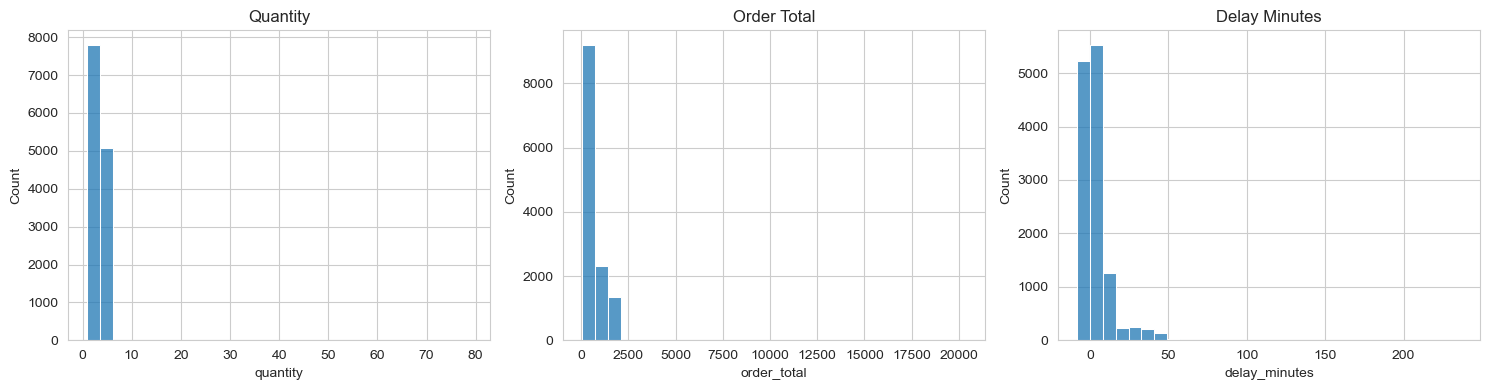

In [55]:
# Step 8: Visual Distribution Check
# Why: confirm visually what the numbers suggest — are these right-skewed distributions with a long tail (expected, don't over-clean) or something structurally broken (multiple clusters, weird gaps)?

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['quantity'], bins=30, ax=axes[0]).set_title('Quantity')
sns.histplot(df['order_total'], bins=30, ax=axes[1]).set_title('Order Total')
sns.histplot(df['delay_minutes'], bins=30, ax=axes[2]).set_title('Delay Minutes')
plt.tight_layout()
plt.show()

Exactly as expected — all three are classic right-skewed distributions: one tall bar of normal values near zero, then a long, thin tail stretching far to the right. No multiple clusters, no weird gaps — just normal business data with a few extreme values pulling the tail out.Note to remember: this confirms Step 7 — IQR

Note to remember: confirms Step 7's decision — percentile capping is the right call, not IQR removal (IQR would treat too much of this natural tail as "wrong").

In [56]:
# Step 9: Cleaning —Fix Invalid Values First
# rating: invalid sentinels -> NaN (so they go through proper imputation, not treated as real)
df.loc[(df['rating'] < 1) | (df['rating'] > 5), 'rating'] = np.nan
df['rating'].isnull().sum()

np.int64(650)

In [57]:
#Step 10: Impute Missing Values
# numeric -> median
for col in ['rating', 'avg_order_value', 'unit_price']:
    df[col] = df[col].fillna(df[col].median())

# categorical -> mode
for col in ['feedback_category', 'payment_method']:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()  # should be 0

np.int64(0)

In [60]:
# Step 11: Handle Outliers (Capping)
# quantity: cap at business-reasonable max (99th percentile)
q_cap = df['quantity'].quantile(0.99)
df['quantity'] = df['quantity'].clip(upper=q_cap)

# order_total: cap at 99th percentile (not IQR — right-skewed, real bulk orders exist)
ot_cap = df['order_total'].quantile(0.99)
df['order_total'] = df['order_total'].clip(upper=ot_cap)

# delay_minutes: cap at 99th percentile
delay_cap = df['delay_minutes'].quantile(0.99)
df['delay_minutes'] = df['delay_minutes'].clip(upper=delay_cap)

print(q_cap, ot_cap, delay_cap)



5.003500000000153 2435.938400000012 60.30800000000672


Why: percentile capping (not IQR removal) per Step 7's decision — trims only the genuinely extreme 1% without deleting real bulk orders/severe delays.

In [61]:
# Step 12: Fix Categorical Text Issues
df['area'] = df['area'].str.strip().str.title()
df['area'].unique()

array(['Noida', 'Pune', 'Kolkata', 'Mumbai', 'Bangalore', 'Ahmedabad',
       'Chandigarh', 'Nagpur', 'Delhi', 'Hyderabad', 'Chennai', 'Gurgaon',
       'Lucknow', 'Jaipur', 'Indore'], dtype=object)

In [62]:
# Step 13: Post-Cleaning Validation
assert df.isnull().sum().sum() == 0
assert (df['rating'] >= 1).all() and (df['rating'] <= 5).all()
assert (df['order_total'] > 0).all()
assert df.duplicated().sum() == 0
assert df['area'].nunique() <= 15
print("All checks passed")
print(df.shape)

All checks passed
(13000, 45)


In [63]:
# Step 14: Feature Engineering Sanity Check
df[['order_hour','day_name','peak_period','sla_breach','delay_minutes','profit','profit_margin']].describe(include='all')

,order_hour,day_name,peak_period,sla_breach,delay_minutes,profit,profit_margin
count,13000.000000,13000,13000,13000.000000,13000.000000,13000.000000,13000.000000
unique,NaN,7,4,NaN,NaN,NaN,NaN
top,NaN,Friday,Evening,NaN,NaN,NaN,NaN
freq,NaN,1947,4910,NaN,NaN,NaN,NaN
mean,14.945077,NaN,NaN,0.132923,3.801065,124.673276,11.504477
std,5.109380,NaN,NaN,0.339505,11.162185,223.483950,12.649767
min,0.000000,NaN,NaN,0.000000,-8.000000,-47.870000,-69.380000
25%,11.000000,NaN,NaN,0.000000,-2.500000,17.680000,7.620000
50%,16.000000,NaN,NaN,0.000000,1.600000,70.695000,15.650000
75%,19.000000,NaN,NaN,0.000000,6.100000,168.430000,19.640000


Why: these derived columns already exist in the data — before doing fresh EDA, confirm they're still internally consistent after our cleaning (capping delay_minutes could affect sla_breach logic if any row's breach status no longer matches its capped delay).

In [64]:
# Step 15: Fix the Inconsistency for above step profit is larger than order_total
# recompute profit/profit_margin for rows where order_total was capped, using consistent cost logic
cogs_pct = 0.76  # midpoint assumption, matches original cost model
delivery_cost = 28
packaging_cost = 6
delay_penalty = np.where(df['sla_breach']==1, 15, 0)

df['profit'] = (df['order_total'] - (df['order_total']*cogs_pct + delivery_cost + packaging_cost + delay_penalty)).round(2)
df['profit_margin'] = (df['profit'] / df['order_total'] * 100).round(2)

df[['order_total','profit','profit_margin']].describe()

,order_total,profit,profit_margin
count,13000.000000,13000.000000,13000.000000
mean,627.621069,114.635258,11.828619
std,527.620049,126.770043,11.849820
min,69.000000,-32.440000,-47.010000
25%,230.595000,19.097500,8.360000
50%,451.975000,72.870000,16.080000
75%,847.707500,167.915000,19.830000
max,2435.938400,550.630000,22.600000


Why: recalculate profit/margin after order_total was capped, so every row stays internally consistent (profit can never exceed its own order's revenue again).

EDA

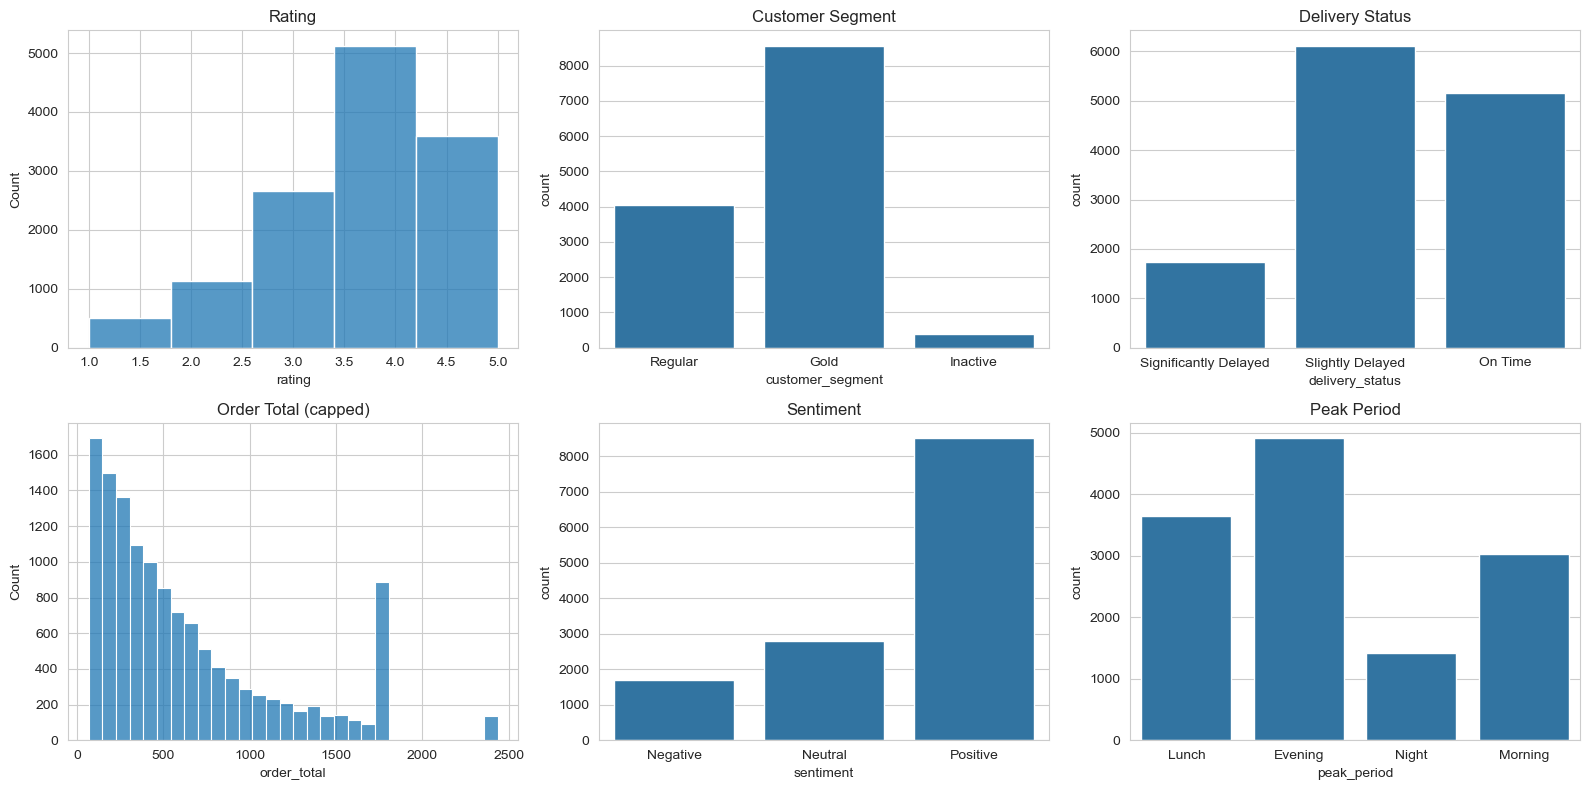

In [65]:
#Step 16: Univariate Analysis — Start the Actual EDA
fig, axes = plt.subplots(2, 3, figsize=(16,8))
sns.histplot(df['rating'], bins=5, ax=axes[0,0]).set_title('Rating')
sns.countplot(x='customer_segment', data=df, ax=axes[0,1]).set_title('Customer Segment')
sns.countplot(x='delivery_status', data=df, ax=axes[0,2]).set_title('Delivery Status')
sns.histplot(df['order_total'], bins=30, ax=axes[1,0]).set_title('Order Total (capped)')
sns.countplot(x='sentiment', data=df, ax=axes[1,1]).set_title('Sentiment')
sns.countplot(x='peak_period', data=df, ax=axes[1,2]).set_title('Peak Period')
plt.tight_layout()
plt.show()

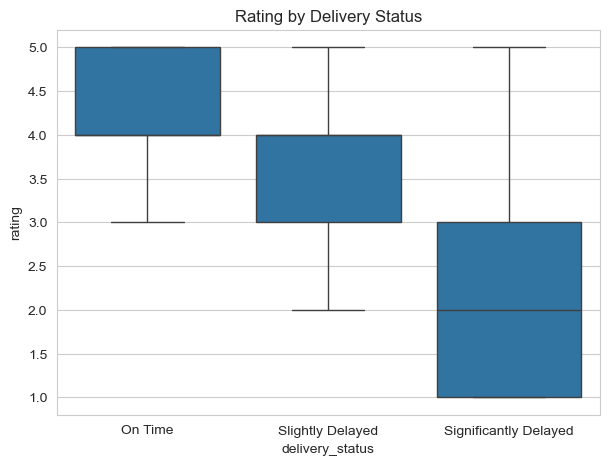

delivery_status
On Time                  4.376747
Significantly Delayed    2.307870
Slightly Delayed         3.704739
Name: rating, dtype: float64

In [66]:
# Step 17: Bivariate Analysis
# — Delivery Status vs Rating
plt.figure(figsize=(7,5))
sns.boxplot(x='delivery_status', y='rating', data=df, order=['On Time','Slightly Delayed','Significantly Delayed'])
plt.title('Rating by Delivery Status')
plt.show()

df.groupby('delivery_status')['rating'].mean()

does delivery experience actually affect customer rating? Moving from univariate (one variable) to bivariate (two variables together).

In [67]:
# Step 18: Bivariate — SLA Breach vs Peak Period
df.groupby('peak_period')['sla_breach'].mean().sort_values(ascending=False) * 100

peak_period
Night      30.358398
Morning    11.661711
Evening    11.344196
Lunch      10.604396
Name: sla_breach, dtype: float64

In [68]:
# Step 19: Bivariate — Revenue/Profit by Peak Period
df.groupby('peak_period').agg(
    orders=('order_id','count'),
    revenue=('order_total','sum'),
    profit=('profit','sum'),
    avg_margin=('profit_margin','mean')
).sort_values('revenue', ascending=False)

,orders,revenue,profit,avg_margin
peak_period,,,,
Evening,4910,3.050087e+06,556726.25,11.896360
Lunch,3640,2.296938e+06,421715.38,11.898310
Morning,3027,1.891048e+06,345638.52,11.866118
Night,1423,9.210008e+05,166178.20,11.336845


In [69]:
# Step 20: Bivariate — Marketing Channel Performance
df.groupby('channel').agg(
    orders=('order_id','count'),
    total_spend=('spend','sum'),
    total_revenue=('revenue_generated','sum'),
    avg_roas=('roas','mean')
).sort_values('avg_roas', ascending=False)

,orders,total_spend,total_revenue,avg_roas
channel,,,,
Instagram,914,181904.28,804000.10,4.420000
YouTube,705,413905.50,1738410.15,4.200000
Facebook,1597,825729.42,3194414.64,3.853682
Email,1409,514867.68,2035344.42,3.365209
Push Notification,1673,320517.05,951079.36,2.965941
Influencer Campaign,881,174526.10,513103.21,2.940000
Social Media,2365,590450.75,1752963.32,2.867175
SMS,1754,479408.66,1242982.04,2.571243
Google Ads,997,261862.05,628468.92,2.400000


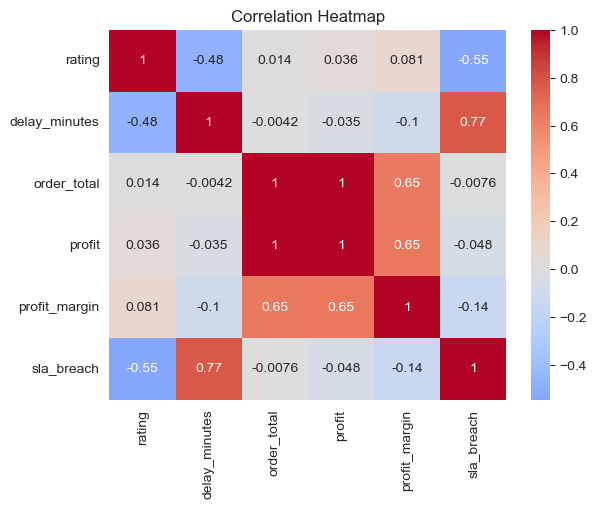

In [70]:
# Step 21: Correlation Check (numeric relationships)
corr_cols = ['rating','delay_minutes','order_total','profit','profit_margin','sla_breach']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [71]:
# Step 22: Final Aggregate Validation (does this match Power BI?)
print("Total Revenue:", df['order_total'].sum())
print("Total Profit:", df['profit'].sum())
print("Overall Margin %:", df['profit'].sum()/df['order_total'].sum()*100)
print("Avg Rating:", df['rating'].mean())
print("SLA Breach %:", df['sla_breach'].mean()*100)

Total Revenue: 8159073.902000002
Total Profit: 1490258.35
Overall Margin %: 18.265042919082997
Avg Rating: 3.7853846153846153
SLA Breach %: 13.292307692307691


In [72]:
df.to_csv("cleaned_from_eda_notebook.csv", index=False)
print("Exported:", df.shape)

Exported: (13000, 45)


In [73]:
df.to_csv(r"D:\DA\projects\SLA_project\cleaned_from_eda_notebook.csv", index=False)